# 01 — NumPyro and the Bayesian Workflow

Starter notebook for the dynestyx [gentle intro tutorial 01](https://basisresearch.github.io/dynestyx/stable/tutorials/gentle_intro/01_numpyro_bayesian_workflow/).

Run the setup cell below to confirm your `.venv` kernel works, then add the tutorial's code cells underneath as you follow along.

In [1]:
# --- Setup / imports ---
import jax
import jax.numpy as jnp
import jax.random as random

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import arviz as az
import matplotlib.pyplot as plt

# Reproducible RNG key (JAX handles randomness explicitly via keys)
rng_key = random.PRNGKey(0)

print("jax       ", jax.__version__)
print("numpyro   ", numpyro.__version__)
print("arviz     ", az.__version__)
print("Setup OK — kernel is working.")

jax        0.9.2
numpyro    0.21.0
arviz      0.23.4
Setup OK — kernel is working.


## Your work starts here

Add the tutorial's code cells below this one. The first one usually **generates synthetic data** (e.g. `y = a*x + b + noise`), then you define a model, run `MCMC(NUTS(model), ...)`, and inspect the posterior with `arviz`.

We will observe  (x,y) and infer  a,  b, and sigma.

 To do so, we must place priors on these parameters in the model.

 We can then generate random x's later, while y will serve as our likelihood as an observation. Observations like y should be labelled y='None' in the argument of the model definition function, while in the numpyro.sample command, it should have obs=y as a parameter. 


First, The code automatically calculates the joint distribution of parameters and data like p(⍴,x,y) that is proportional to the posterior we sample, so we just need to define the random variables individually.  



In [5]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist

numpyro.util.set_host_device_count(4)  # to sample chains in parallel later


def linear_regression_model(x, y=None):
    """y = a*x + b + noise. We observe (x, y); infer a, b, sigma."""
    a = numpyro.sample("a", dist.Normal(0.0, 2.0))
    b = numpyro.sample("b", dist.Normal(0.0, 2.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = a * x + b
    numpyro.sample("y", dist.Normal(mu, sigma), obs=y)

Generate data below. First manually generate data

In [9]:
#Manually
# Generate synthetic data: y = a*x + b + noise
key = jr.PRNGKey(0)
a_true, b_true = 1.5, -0.5
sigma_true = 0.3
n = 80
key, kx, kn = jr.split(key, 3)
x_data = jr.uniform(kx, (n,), minval=-2.0, maxval=2.0)
y_data = a_true * x_data + b_true + sigma_true * jr.normal(kn, (n,))

print("True: a =", a_true, ", b =", b_true, ", sigma =", sigma_true)
print("Data: x =", x_data, ", y =", y_data)


True: a = 1.5 , b = -0.5 , sigma = 0.3
Data: x = [-1.9708247  -1.9164352   0.325706   -0.55264807 -1.1078491  -1.5228467
 -1.4982443   0.46731997 -1.6199708   1.9336901  -0.30071163  1.3299203
 -1.6135516  -1.0919166  -0.5817008   0.6841655  -1.5321426  -0.11042786
 -1.3219151  -1.8997192  -1.462542   -0.50510263  1.6331806   1.1666884
 -1.5069442  -0.8260727   1.1616235   1.8039904  -0.6353755   0.08595181
 -0.96653223 -1.8457432  -0.33505297  1.2873921  -1.6120286  -1.0506306
 -1.9674277  -1.812952   -0.72305536 -1.8272948  -1.906538   -1.8024096
 -0.43252134 -1.0556817   0.6114392  -1.3066635   1.8894305   0.8445358
 -0.12612295  1.1139317   1.2806249  -1.4848528   1.0201001  -1.6608634
  0.29509592 -1.7826605  -0.729301    0.7660985  -1.0921369   1.3340573
 -0.48498297  0.03042221  1.4182234   1.2989359   1.8234167   1.1109018
  1.6884294  -1.4818125   0.9170089   0.96435213 -1.5643296   1.5919428
 -0.00644588 -0.16934347  0.02836132  1.0394487   0.8587971  -0.331141
 -0.64232063  

In [14]:
#Using the Predictive utility
from numpyro.infer import Predictive

x_grid = jnp.linspace(-2, 2, 50)

# (1) Generate data from the model with fixed parameters (like our "true" data)
prior_predictive_fixed = Predictive(
    linear_regression_model,
    num_samples=4,
    params={
        #Inserting values here overwrites the sampling of these parameters, 
        # so we get deterministic samples of y based on the fixed a, b, sigma below
        "a": jnp.array(a_true),
        "b": jnp.array(b_true),
        "sigma": jnp.array(sigma_true),
    },
)
prior_pred_fixed = prior_predictive_fixed(jr.PRNGKey(2), x=x_grid)
print(prior_pred_fixed.keys())  # should show 'a', 'b', 'sigma', 'y'
print("Shapes:", {k: v.shape for k, v in prior_pred_fixed.items()})
print("Sampled y (fixed params):", prior_pred_fixed["y"])

#In contrast, this generates the data based on our priors
# (2) Prior predictive: sample (a, b, sigma) from prior, then y | x
prior_predictive_full = Predictive(linear_regression_model, num_samples=20)
prior_pred_full = prior_predictive_full(jr.PRNGKey(3), x=x_grid)

dict_keys(['a', 'b', 'sigma', 'y'])
Shapes: {'a': (4,), 'b': (4,), 'sigma': (4,), 'y': (4, 50)}
Sampled y (fixed params): [[-3.1694818  -3.434756   -3.2706673  -2.8266788  -2.4920657  -3.0959973
  -2.8338444  -2.763167   -2.5864608  -1.9805517  -2.3939114  -2.4398756
  -1.2330773  -2.2505383  -2.6601484  -1.5417619  -1.8801187  -1.4006307
  -1.7907178  -1.0319937  -0.6314849  -1.1532931  -0.6677677  -0.69801503
  -0.07266386 -0.6118033  -0.5172571  -0.67294806  0.16386509  0.11320539
  -0.00988447  0.30824897  0.52987266  1.0327121   0.7788434   0.97315365
   0.75952697  0.65347373  1.2865962   1.3574432   1.7438482   1.8151548
   1.7261161   1.9365435   2.3712623   1.6019783   2.5126162   1.6928003
   2.5877037   2.605124  ]
 [-3.3938558  -2.878629   -3.1398337  -2.8363545  -2.92906    -2.8904955
  -2.7944658  -2.7370799  -2.2040222  -2.448795   -2.3264859  -2.4608252
  -2.4113872  -2.139717   -1.6177524  -1.7798983  -1.9137064  -1.7214638
  -0.8106278  -1.6036428  -0.919265   -1.4042

Performing Statistical Inference with NUTS

In [15]:
from numpyro.infer import MCMC, NUTS

nuts_kernel = NUTS(linear_regression_model)
mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=1000, num_chains=4)
mcmc.run(jr.PRNGKey(1), x=x_data, y=y_data)

posterior_grouped_by_chain = mcmc.get_samples(group_by_chain=True)  # for diagnostics
posterior = mcmc.get_samples(group_by_chain=False)  # for posterior predictive

print("Posterior keys:", posterior_grouped_by_chain.keys())
print("Posterior shapes:", {k: v.shape for k, v in posterior_grouped_by_chain.items()})
print("Posterior a mean:", jnp.mean(posterior["a"]))
print("Posterior b mean:", jnp.mean(posterior["b"]))
print("Posterior sigma mean:", jnp.mean(posterior["sigma"]))


/var/folders/hf/qh_x6xkx797d10rzhs_jhfmh0000gn/T/ipykernel_54226/3970575649.py:4: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=1000, num_chains=4)
sample: 100%|██████████| 1500/1500 [00:00<00:00, 10575.60it/s, 7 steps of size 8.04e-01. acc. prob=0.90]


Posterior keys: dict_keys(['a', 'b', 'sigma'])
Posterior shapes: {'a': (4, 1000), 'b': (4, 1000), 'sigma': (4, 1000)}
Posterior a mean: 1.4869813
Posterior b mean: -0.46564266
Posterior sigma mean: 0.29723573


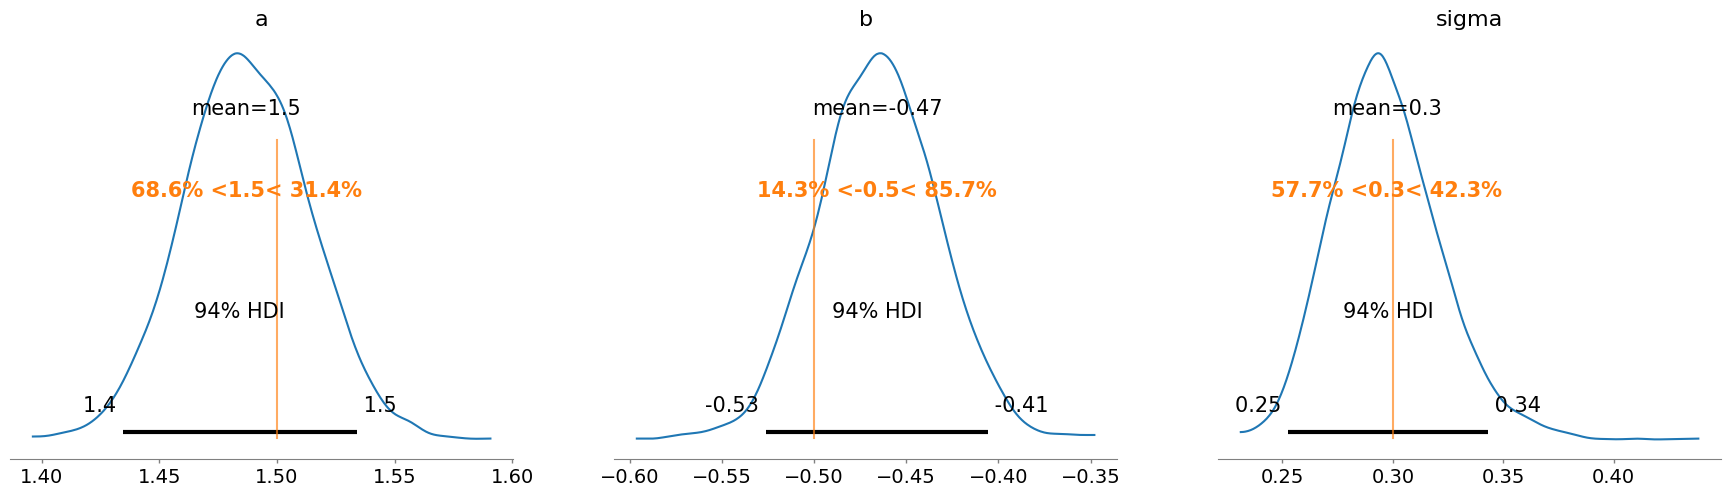

In [16]:
import arviz as az

idata = az.from_dict(posterior=posterior_grouped_by_chain)
az.plot_posterior(
    idata, var_names=["a", "b", "sigma"], ref_val=[a_true, b_true, sigma_true]
);

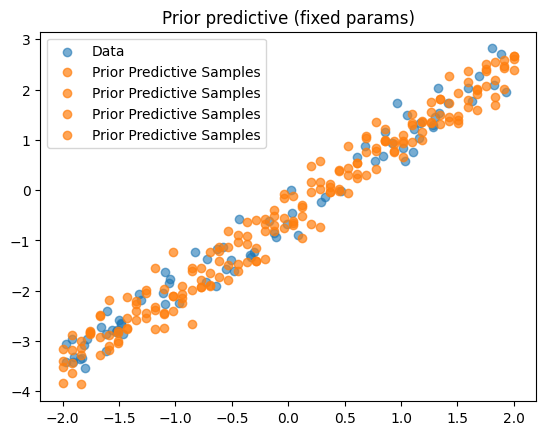

In [ ]:
#Prior Predictive Check with Fixed Parameters (simply a format)
import matplotlib.pyplot as plt

plt.scatter(x_data, y_data, alpha=0.6, label="Data")
for i in range(min(4, prior_pred_fixed["y"].shape[0])):
    plt.scatter(
        x_grid,
        prior_pred_fixed["y"][i],
        alpha=0.7,
        marker="o",
        color="C1",
        label="Prior Predictive Samples",
    )
plt.title("Prior predictive (fixed params)")
plt.legend()

plt.show()

Actual Prior Predictives are checked when we put a prior over the samples

In [ ]:
# (2) Prior predictive: sample (a, b, sigma) from prior, then y | x
# Notice that we left out the parameters in the Predictive call, so it samples them from the prior
prior_predictive_full = Predictive(linear_regression_model, num_samples=20)
prior_pred_full = prior_predictive_full(jr.PRNGKey(3), x=x_grid)


for i in range(prior_pred_full["y"].shape[0]):
    plt.scatter(
        x_grid,
        prior_pred_full["y"][i],
        alpha=0.4,
        edgecolors=f"C{i + 1}",
        facecolors="none",
    )

plt.scatter(
    [], [], label="Prior Predictive Samples", edgecolors="C0", facecolors="none"
)
plt.scatter(x_data, y_data, alpha=1.0, label="Data", color="black")
plt.title("Prior predictive (prior over params)")
plt.legend()

plt.show()

Posterior Predictive check: use the Predicitve object again to generate data based on the parameters we infer from NUTS. We build a confidence interval out of data forecasted by the posterior parametersand see if real world data fits in it. 

Simply in the arguments of the Predictive object insert posterior_samples = posterior (dictionary of posterior not grouped by chain). The num_samples is the total number of data points stored in the posterior dictionary (otherwise it will randomly select values from our posterior sample/duplicate values). 

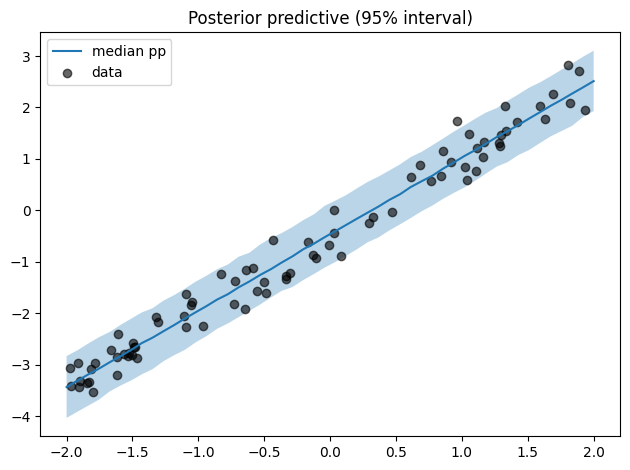

In [18]:
# (3) Posterior predictive: sample (a, b, sigma) from posterior, then y | x
posterior_predictive = Predictive(
    linear_regression_model,
    posterior_samples=posterior,
    num_samples=4_000,
)
post_pred = posterior_predictive(jr.PRNGKey(3), x=x_grid)


y_pp = post_pred["y"]
plt.fill_between(
    x_grid,
    jnp.percentile(y_pp, 2.5, axis=0),
    jnp.percentile(y_pp, 97.5, axis=0),
    alpha=0.3,
)
plt.plot(x_grid, jnp.median(y_pp, axis=0), color="C0", label="median pp")
plt.scatter(x_data, y_data, alpha=0.6, color="black", label="data")
plt.title("Posterior predictive (95% interval)")
plt.legend()
plt.tight_layout()
plt.show()
